# Context

### In this notebook, I Fine Tune a Pre-Trained GPT-2 (Decoder only Transformer) Model on IMDB Moview Review Classification Dataset.  

#### The complete pipeline is:

**Movie review → GPT-2 tokenizer → token IDs and attention mask → GPT-2 → classification head → negative or positive**

There are two distinct stages.

1. **Pretraining.** GPT-2 has already learned general language patterns by predicting the next token across a large text corpus.
2. **Fine-tuning.** We update those pretrained weights, together with a new classification head, using labelled IMDB reviews.

# 1. Environment Setup

In [2]:
%pip install -q "transformers==4.45.2" "datasets==3.0.1" "accelerate==0.34.2" scikit-learn pandas matplotlib

Note: you may need to restart the kernel to use updated packages.


### 1.1 Import libraries and choose the experiment settings

A fixed random seed makes sampling and training more reproducible. GPU calculations can still vary slightly between runs.

In [3]:
import os
import random

os.environ["WANDB_DISABLED"] = "true"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from datasets import load_dataset
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    precision_recall_fscore_support,
)
from transformers import (
    GPT2ForSequenceClassification,
    GPT2Tokenizer,
    Trainer,
    TrainingArguments,
    set_seed,
)

from helper_functions import balanced_subset, get_label_distribution, get_demo_tokenization_table

SEED = 42
MODEL_NAME = "gpt2"
MAX_LENGTH = 64
TRAIN_SAMPLES = 500
VALIDATION_SAMPLES = 100
TEST_SAMPLES = 100
NUM_EPOCHS = 5
LABEL_NAMES = {0: "negative", 1: "positive"}


random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
set_seed(SEED)

if torch.cuda.is_available():
    device_name = torch.cuda.get_device_name(0)
elif torch.backends.mps.is_available():
    device_name = "Apple Silicon (MPS)"
else:
    device_name = "CPU"
print(f"Runtime device: {device_name}")

/Users/mldevpilot/opt/miniconda3/envs/llm/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Runtime device: Apple Silicon (MPS)


---
## 2. Load and explore the IMDB dataset

The IMDB dataset contains movie reviews with binary sentiment labels.

| Label | Meaning |
|---|---|
| 0 | Negative review |
| 1 | Positive review |

The full dataset contains 25,000 labelled training reviews and 25,000 labelled test reviews, plus an unsupervised split that we do not use here.

We will create three small subsets.

- **Training.** Used to update model parameters.
- **Validation.** Checked after each epoch.
- **Test.** Held back until training is finished.

Keeping the test set separate gives us a less biased final estimate of performance.

In [4]:
raw_dataset = load_dataset("stanfordnlp/imdb")

print(raw_dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})


In [5]:
print("\nAvailable label names,", raw_dataset["train"].features["label"].names)


Available label names, ['neg', 'pos']


In [6]:
# Access a random review from the training set
random_review = raw_dataset["train"][10002]

print("Random Review:")
print(random_review["text"])

print("\nCorresponding Label:", random_review["label"])


Random Review:
I cant believe blockbuster carries this movie. It was SO BAD. I was totally fooled by the box art. DON'T BE FOOLED!! Its not worth your time I promise you. I don't know if the positive reviews for this flick were a joke or what. I am so disappointed. :( <br /><br />The description on the back of the box doesn't even match! The girl that has the voodoo done on her is a stripper. The synopsis on the back says she is only 17. Did the people writing the description for the film even bother to watch it!? Those positive reviews had to be a joke they just had to be. If anyone actually liked this flick then I've lost all faith in humanity.<br /><br />And don't even get me started on the story compared to the title. Or the fact that the entire movie was done all in 2 locations. Or that the cops didn't even have close to real uniforms. Why would i even say that?? Who cares about the cops uniforms!? Compared to the rest of the movie the uniforms were spot on. <br /><br />This movie

### 2.1 Build representative, reproducible subsets



In [7]:
train_validation_pool = raw_dataset["train"].train_test_split(
    test_size=0.2,
    seed=SEED,
    stratify_by_column="label",
)

train_reviews = balanced_subset(
    train_validation_pool["train"], TRAIN_SAMPLES, seed=SEED
)
validation_reviews = balanced_subset(
    train_validation_pool["test"], VALIDATION_SAMPLES, seed=SEED + 1
)
test_reviews = balanced_subset(
    raw_dataset["test"], TEST_SAMPLES, seed=SEED + 2
)

In [8]:
get_label_distribution(train_reviews,validation_reviews, test_reviews)

,negative,positive
Split,,
Training,250,250
Validation,50,50
Test,50,50


In [9]:
validation_reviews["text"][0]

'but there are not too many of them. Probably the worst "major release" film I have seen in my life. Definitely the worst for this year. There is no point in commenting on the plot, the cast or the acting. The problem is beyond all that. It lays in the absolute stupidity of the annoying kind (not the funny kind) of everything that takes place on the screen. I don\'t know why I gave it a 2/10 instead of 1/10. Probably, because of Steven Martini. He really did try. Bottom line - 95 minutes washed down the toilet along with a few brain cells. Avoid at any cost.'

In [10]:
validation_reviews["label"][0]

0

---
## 3. Turn reviews into model inputs

The tokenizer converts each review into model inputs.

1. Split text into GPT-2 tokens.
2. Convert tokens into integer **input IDs**.
3. Truncate sequences longer than **MAX_LENGTH**.
4. Pad shorter sequences so a batch has one consistent shape.
5. Create an **attention mask**, 1 for real tokens and 0 for padding.

### Why does GPT-2 need a padding setup?

GPT-2 was pretrained for continuous text generation and does not define a padding token by default. For classification batches, we reuse its end-of-text token as padding and tell the model which token ID is being used.

The attention mask ensures that padded positions are ignored.

In [10]:
tokenizer = GPT2Tokenizer.from_pretrained(MODEL_NAME)

In [11]:
tokenizer.eos_token

'<|endoftext|>'

In [12]:
tokenizer.pad_token is None

True

In [13]:
tokenizer.pad_token = tokenizer.eos_token

### 3.1 Inspect one tokenized review

GPT-2 uses byte-pair encoding. A token may be a word, punctuation mark, or part of a word. In the token display below, the special character **Ġ** usually marks a token that begins after a space.

We use a short maximum length only for this demonstration so that the table remains readable.

In [14]:
get_demo_tokenization_table(tokenizer)

Original review:
The performances were excellent, but the story was painfully predictable.



,position,token,input_id,attention_mask
0,0,The,464,1
1,1,Ġperformances,13289,1
2,2,Ġwere,547,1
3,3,Ġexcellent,6275,1
4,4,",",11,1
5,5,Ġbut,475,1
6,6,Ġthe,262,1
7,7,Ġstory,1621,1
8,8,Ġwas,373,1
9,9,Ġpainfully,32258,1


### 3.2 Tokenize all three subsets

The function below is applied to batches of reviews with dataset.map(...).

We use fixed-length padding here because it makes tensor shapes easy to inspect. 

In [15]:
def tokenize_batch(examples):
    return tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=MAX_LENGTH,
    )


tokenized_train = train_reviews.map(
    # function name
    tokenize_batch,
    # Process multiple examples at once
    batched=True,
    # remove the original text column 
    remove_columns=["text"],
)
tokenized_validation = validation_reviews.map(
    tokenize_batch,
    batched=True,
    remove_columns=["text"],
)
tokenized_test = test_reviews.map(
    tokenize_batch,
    batched=True,
    remove_columns=["text"],
)

In [16]:
print(type(tokenized_validation["label"]))

<class 'list'>


In [17]:
# This configures the Hugging Face tokenized_train dataset to return selected fields as PyTorch tensors:
tensor_columns = ["input_ids", "attention_mask", "label"]
tokenized_train.set_format("torch", columns=tensor_columns)
tokenized_validation.set_format("torch", columns=tensor_columns)
tokenized_test.set_format("torch", columns=tensor_columns)

In [18]:
print(type(tokenized_validation["label"]))

<class 'torch.Tensor'>


In [19]:
first_example = tokenized_train[0]

print("Input ID shape,", tuple(first_example["input_ids"].shape))
print("Attention-mask shape,", tuple(first_example["attention_mask"].shape))
print("Label,", first_example["label"].item(), "-", LABEL_NAMES[first_example["label"].item()])
print("Real tokens,", int(first_example["attention_mask"].sum()))
print("Padding positions,", int((first_example["attention_mask"] == 0).sum()))

Input ID shape, (64,)
Attention-mask shape, (64,)
Label, 1 - positive
Real tokens, 64
Padding positions, 0


---
## 4. Load GPT-2 with a classification head

GPT2ForSequenceClassification contains.

- the pretrained GPT-2 Transformer.
- a newly created linear head that outputs two logits.

Hugging Face will report that the classification-head weights are newly initialized. That is expected, the original GPT-2 checkpoint did not contain a sentiment classifier. Fine-tuning will learn these weights.

We also set the model's padding-token ID so it can locate the last real token in each padded sequence.

In [20]:
set_seed(SEED)  # Reproduce the randomly initialized classification head

model = GPT2ForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label=LABEL_NAMES,
    label2id={"negative": 0, "positive": 1},
)
model.config.pad_token_id = tokenizer.pad_token_id

parameter_count = sum(parameter.numel() for parameter in model.parameters())
print(f"\n\nModel parameters: {parameter_count:,}")

Some weights of GPT2ForSequenceClassification were not initialized from the model checkpoint at gpt2 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.




Model parameters: 124,441,344


In [21]:
# Save original/baseline model
model.save_pretrained("./saved_models/gpt2-imdb-baseline")

In [22]:
# Save the tokenizer
tokenizer.save_pretrained("./saved_models/saved_tokenizer")

('./saved_models/saved_tokenizer/tokenizer_config.json',
 './saved_models/saved_tokenizer/special_tokens_map.json',
 './saved_models/saved_tokenizer/vocab.json',
 './saved_models/saved_tokenizer/merges.txt',
 './saved_models/saved_tokenizer/added_tokens.json')

## 5. Define the evaluation metrics

For binary classification, the following metrics answer different questions.

| Metric | Meaning |
|---|---|
| **Accuracy** | Fraction of all reviews classified correctly |
| **Precision** | When the model predicts a class, how often is it correct? |
| **Recall** | Of the reviews belonging to a class, how many did the model find? |
| **F1-score** | Harmonic mean of precision and recall |

In [23]:
def compute_metrics(evaluation_prediction):
    logits = evaluation_prediction.predictions
    labels = evaluation_prediction.label_ids
    predictions = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="macro",
        zero_division=0,
    )

    return {
        "accuracy": accuracy_score(labels, predictions),
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

---
## 6. Configure fine-tuning

Important settings in TrainingArguments.

| Setting | Value | Purpose |
|---|---:|---|
| Learning rate | 5 × 10⁻⁵ | Size of each parameter update |
| Training batch size | 4 | Reviews processed before one update |
| Epochs | 3 | Passes through the training subset |
| Weight decay | 0.01 | Regularisation that discourages overly large weights |
| Evaluation strategy | Every epoch | Measure validation performance after each pass |
| Save strategy | Every Epoch | Avoid unnecessary checkpoints in this short workshop |


In [24]:
training_args = TrainingArguments(
    output_dir="./gpt2-imdb-checkpoints",
    eval_strategy="epoch",
    logging_strategy="epoch",
    save_strategy="epoch",
    learning_rate=5e-5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=8,
    num_train_epochs=NUM_EPOCHS,
    weight_decay=0.01,
    report_to="none",
    seed=SEED,
    data_seed=SEED,
    fp16=torch.cuda.is_available()
)

### 6.1 Create the Trainer

The Trainer coordinates batching, gradient calculation, optimisation, logging, and validation. The validation set is supplied here because it will be evaluated after every epoch.

We will use test set only after fine-tuning is complete.

In [25]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_validation,
    compute_metrics=compute_metrics,
)

---
## 7. Evaluate before fine-tuning

This baseline measures the pretrained GPT-2 backbone plus its **randomly initialized classification head**.

In [26]:
baseline_metrics = trainer.evaluate(metric_key_prefix="baseline")

baseline_summary = pd.Series(
    {
        "baseline_loss": baseline_metrics["baseline_loss"],
        "baseline_accuracy": baseline_metrics["baseline_accuracy"],
        "baseline macro precision": baseline_metrics["baseline_precision"],
        "baseline macro recall": baseline_metrics["baseline_recall"],
        "baseline macro F1": baseline_metrics["baseline_f1"],
    },
    name="Before fine-tuning",
)

baseline_summary.round(4)

/Users/mldevpilot/opt/miniconda3/envs/llm/lib/python3.10/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
100%|██████████| 13/13 [00:00<00:00, 23.51it/s]


baseline_loss               7.1941
baseline_accuracy           0.5000
baseline macro precision    0.2500
baseline macro recall       0.5000
baseline macro F1           0.3333
Name: Before fine-tuning, dtype: float64

Note on parallel processing:

batch size = 4

so 4 inputs processes in parallel in 1 step.

total 500 inputs.

500/4 = 125.

so we need 125 steps for 1 epoch (completely seeing the training data once)

---
## 8. Fine-tune the model

trainer.train() performs three complete passes through the training subset.

At each training step.

1. GPT-2 produces two logits for every review.
2. Cross-entropy loss compares the logits with the correct labels.
3. Backpropagation calculates gradients.
4. The optimiser updates the model parameters.

After each epoch, the Trainer evaluates the current model on the validation subset.

> Falling training loss with worsening validation performance is a warning sign for overfitting.

In [28]:
train_result = trainer.train()

  2%|▏         | 10/625 [00:11<11:28,  1.12s/it]

                                              

{'loss': 1.0364, 'grad_norm': 17.44470977783203, 'learning_rate': 4e-05, 'epoch': 1.0}


 85%|████████▍ | 11/13 [00:00<00:00, 24.64it/s]


{'eval_loss': 0.7183454632759094, 'eval_model_preparation_time': 0.0051, 'eval_accuracy': 0.57, 'eval_precision': 0.6372549019607843, 'eval_recall': 0.5700000000000001, 'eval_f1': 0.50997150997151, 'eval_runtime': 0.6721, 'eval_samples_per_second': 148.797, 'eval_steps_per_second': 19.344, 'epoch': 1.0}


/Users/mldevpilot/opt/miniconda3/envs/llm/lib/python3.10/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)

                                              

...

{'loss': 0.0861, 'grad_norm': 0.0958467423915863, 'learning_rate': 0.0, 'epoch': 5.0}


100%|██████████| 13/13 [00:00<00:00, 25.19it/s]


{'eval_loss': 1.5970046520233154, 'eval_model_preparation_time': 0.0051, 'eval_accuracy': 0.73, 'eval_precision': 0.7377015295576685, 'eval_recall': 0.73, 'eval_f1': 0.7277951406391774, 'eval_runtime': 0.5703, 'eval_samples_per_second': 175.347, 'eval_steps_per_second': 22.795, 'epoch': 5.0}



100%|██████████| 625/625 [04:54<00:00,  2.13it/s]

{'train_runtime': 294.0877, 'train_samples_per_second': 8.501, 'train_steps_per_second': 2.125, 'train_loss': 0.47313313751220704, 'epoch': 5.0}


In [29]:
print(f"Training runtime, {train_result.metrics['train_runtime']:.1f} seconds")

Training runtime, 294.1 seconds


In [30]:
print(f"Final average training loss, {train_result.metrics['train_loss']:.4f}")

Final average training loss, 0.4731


In [32]:
# Save fine-tuned model
model.save_pretrained("./saved_models/gpt2-imdb-finetuned")
tokenizer.save_pretrained("./saved_models/gpt2-imdb-finetuned")

('./saved_models/gpt2-imdb-finetuned/tokenizer_config.json',
 './saved_models/gpt2-imdb-finetuned/special_tokens_map.json',
 './saved_models/gpt2-imdb-finetuned/vocab.json',
 './saved_models/gpt2-imdb-finetuned/merges.txt',
 './saved_models/gpt2-imdb-finetuned/added_tokens.json')

### 8.1 Building a clean epoch-by-epoch results table

In [31]:
training_loss_by_epoch = {}
validation_logs = []

for record in trainer.state.log_history:
    if "epoch" not in record:
        continue

    epoch_key = round(float(record["epoch"]), 4)

    if "loss" in record and "eval_loss" not in record:
        training_loss_by_epoch[epoch_key] = record["loss"]

    if "eval_loss" in record:
        validation_logs.append(record)

history_rows = [
    {
        "epoch": 0.0,
        "training_loss": np.nan,
        "validation_loss": baseline_metrics["baseline_loss"],
        "accuracy": baseline_metrics["baseline_accuracy"],
        "precision": baseline_metrics["baseline_precision"],
        "recall": baseline_metrics["baseline_recall"],
        "f1": baseline_metrics["baseline_f1"],
    }
]

for record in validation_logs:
    epoch = round(float(record["epoch"]), 4)
    history_rows.append(
        {
            "epoch": epoch,
            "training_loss": training_loss_by_epoch.get(epoch, np.nan),
            "validation_loss": record["eval_loss"],
            "accuracy": record["eval_accuracy"],
            "precision": record["eval_precision"],
            "recall": record["eval_recall"],
            "f1": record["eval_f1"],
        }
    )

history_table = pd.DataFrame(history_rows)
history_table.round(4)

,epoch,training_loss,validation_loss,accuracy,precision,recall,f1
0,0.0,NaN,7.1941,0.50,0.2500,0.50,0.3333
1,1.0,1.0364,0.7183,0.57,0.6373,0.57,0.5100
2,2.0,0.6471,0.7351,0.67,0.6987,0.67,0.6576
3,3.0,0.4069,1.1107,0.69,0.7148,0.69,0.6808
4,4.0,0.1892,1.3045,0.73,0.7323,0.73,0.7293
5,5.0,0.0861,1.5970,0.73,0.7377,0.73,0.7278


### 8.2 Plot loss and validation metrics

- **Left.** Training and validation loss. Lower is better.
- **Right.** Validation metrics. Higher is better.

Epoch 0 is the pre-training baseline. It has validation results but no training loss.

The validation subset contains 50 examples from each class. With equal class support, accuracy and macro recall have the same value in this run. The recall line would otherwise cover the accuracy line exactly. Accuracy is therefore shown as large hollow blue markers above the recall line.

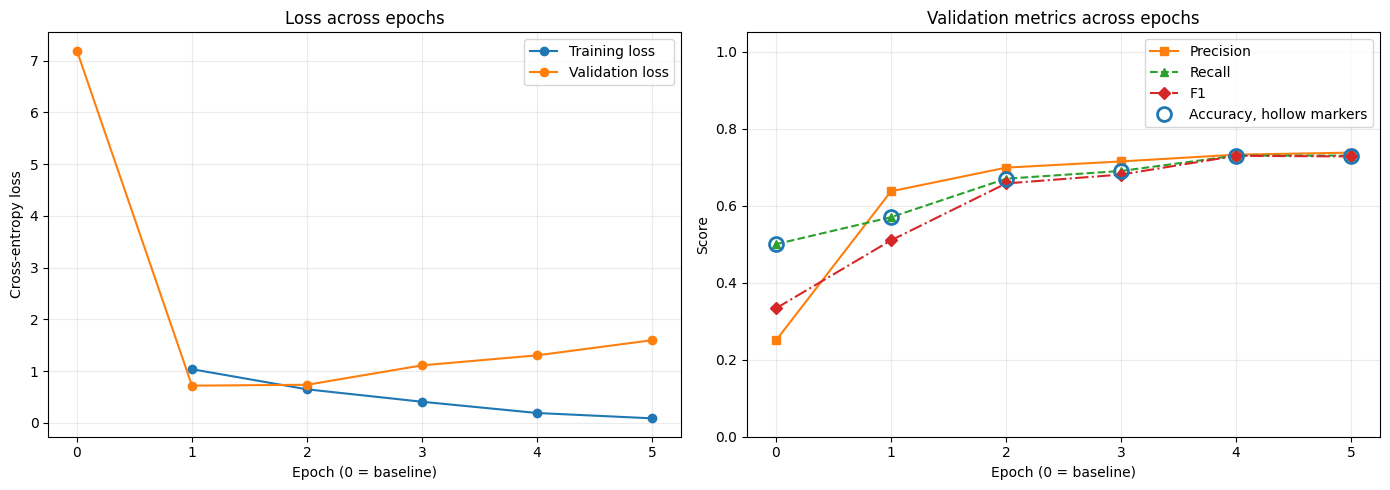

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

has_training_loss = history_table["training_loss"].notna()
axes[0].plot(
    history_table.loc[has_training_loss, "epoch"],
    history_table.loc[has_training_loss, "training_loss"],
    marker="o",
    label="Training loss",
)
axes[0].plot(
    history_table["epoch"],
    history_table["validation_loss"],
    marker="o",
    label="Validation loss",
)
axes[0].set_title("Loss across epochs")
axes[0].set_xlabel("Epoch (0 = baseline)")
axes[0].set_ylabel("Cross-entropy loss")
axes[0].set_xticks(history_table["epoch"])
axes[0].legend()
axes[0].grid(alpha=0.25)

metric_styles = {
    "precision": {"color": "tab:orange", "marker": "s", "linestyle": "-"},
    "recall": {"color": "tab:green", "marker": "^", "linestyle": "--"},
    "f1": {"color": "tab:red", "marker": "D", "linestyle": "-."},
}

for metric, style in metric_styles.items():
    axes[1].plot(
        history_table["epoch"],
        history_table[metric],
        label=metric.title(),
        **style,
    )

axes[1].plot(
    history_table["epoch"],
    history_table["accuracy"],
    linestyle="none",
    marker="o",
    markersize=10,
    markerfacecolor="none",
    markeredgecolor="tab:blue",
    markeredgewidth=2,
    label="Accuracy, hollow markers",
    zorder=5,
)

axes[1].set_title("Validation metrics across epochs")
axes[1].set_xlabel("Epoch (0 = baseline)")
axes[1].set_ylabel("Score")
axes[1].set_ylim(0, 1.05)
axes[1].set_xticks(history_table["epoch"])
axes[1].legend()
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

---
## 9. Final evaluation on the held-out test subset

Now that fine-tuning is complete, we evaluate the test subset once.

The confusion matrix shows where predictions went.

| Position | Meaning |
|---|---|
| Top-left | Negative reviews predicted as negative |
| Top-right | Negative reviews predicted as positive |
| Bottom-left | Positive reviews predicted as negative |
| Bottom-right | Positive reviews predicted as positive |

A good classifier has large values on the diagonal.

/Users/mldevpilot/opt/miniconda3/envs/llm/lib/python3.10/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
100%|██████████| 13/13 [00:00<00:00, 24.82it/s]


loss               2.0399
accuracy           0.6800
macro precision    0.6803
macro recall       0.6800
macro F1           0.6799
Name: Held-out test subset, dtype: float64

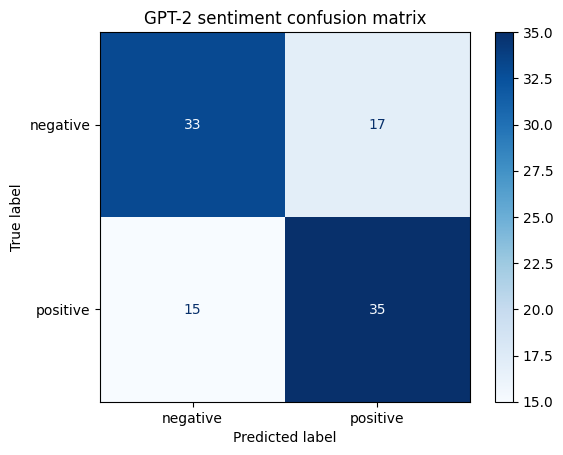

In [34]:
test_output = trainer.predict(
    tokenized_test,
    metric_key_prefix="test",
)

test_summary = pd.Series(
    {
        "loss": test_output.metrics["test_loss"],
        "accuracy": test_output.metrics["test_accuracy"],
        "macro precision": test_output.metrics["test_precision"],
        "macro recall": test_output.metrics["test_recall"],
        "macro F1": test_output.metrics["test_f1"],
    },
    name="Held-out test subset",
)
display(test_summary.round(4))

test_predictions = np.argmax(test_output.predictions, axis=-1)
matrix = confusion_matrix(
    test_output.label_ids,
    test_predictions,
    labels=[0, 1],
)

ConfusionMatrixDisplay(
    confusion_matrix=matrix,
    display_labels=["negative", "positive"],
).plot(cmap="Blues")
plt.title("GPT-2 sentiment confusion matrix")
plt.show()

---
## 10. Use the fine-tuned model on new reviews

For inference.

1. Tokenize the review.
2. Move the tensors to the same device as the model.
3. Run a forward pass without gradients.
4. Apply softmax to convert logits into probabilities.
5. Select the class with the largest probability.

In [ ]:
def predict_sentiment(review):
    encoded = tokenizer(
        review,
        return_tensors="pt", # Returns the tokens as PyTorch tensors.
        truncation=True,
        max_length=MAX_LENGTH,
    ).to(model.device)

    # Puts the model into prediction mode.
    model.eval()

    # Disables gradient calculation because no training is needed.
    with torch.no_grad():
        # Runs the model and gets raw sentiment scores.
        logits = model(**encoded).logits

    # Converts the raw scores into negative review and positive review probabilities.
    probabilities = torch.softmax(logits, dim=-1)[0].cpu().numpy()
    
    # Finds the class with the highest probability.
    predicted_label = int(np.argmax(probabilities))

    return {
        "review": review,
        "prediction": LABEL_NAMES[predicted_label],
        "negative probability": probabilities[0],
        "positive probability": probabilities[1],
    }

In [37]:
new_reviews = [
    "A clever, moving film with excellent performances.",
    "The plot was tedious and the characters were completely forgettable.",
    "The visuals were impressive, although the story never quite came together.",
]

prediction_table = pd.DataFrame(
    [predict_sentiment(review) for review in new_reviews]
)

prediction_table.style.format(
    {
        "negative probability": "{:.3f}",
        "positive probability": "{:.3f}",
    }
)

,review,prediction,negative probability,positive probability
0,"A clever, moving film with excellent performances.",positive,0.041,0.959
1,The plot was tedious and the characters were completely forgettable.,negative,1.000,0.000
2,"The visuals were impressive, although the story never quite came together.",negative,0.999,0.001
